# Regression A

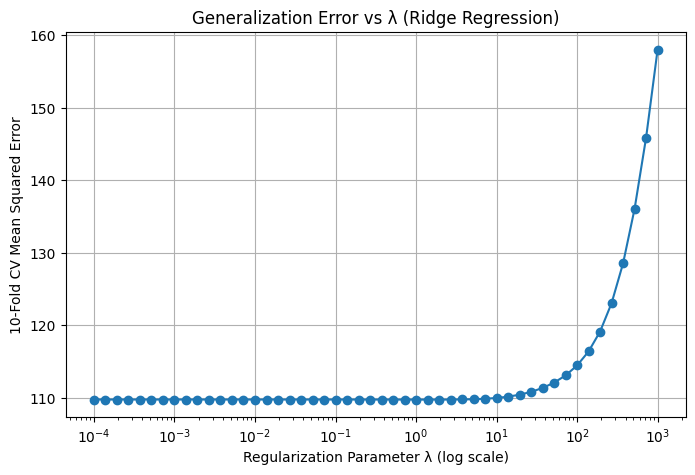

Best λ: 1.389495494373136
Cement (component 1)(kg in a m^3 mixture) : 12.2691
Blast Furnace Slag (component 2)(kg in a m^3 mixture) : 8.7180
Fly Ash (component 3)(kg in a m^3 mixture) : 5.4135
Water  (component 4)(kg in a m^3 mixture) : -3.3701
Superplasticizer (component 5)(kg in a m^3 mixture) : 1.7390
Coarse Aggregate  (component 6)(kg in a m^3 mixture) : 1.2368
Fine Aggregate (component 7)(kg in a m^3 mixture) : 1.4025
Age (day)                 : 7.1911


In [2]:
import argparse
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import KFold, cross_val_score
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import Ridge

df = pd.read_excel("Concrete_Data.xls")

X = df.iloc[:, :-1]   # all columns except the last one
y = df.iloc[:, -1]    # the last column (strength)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

lambdas = np.logspace(-4, 3, 50)  # λ values from 10^-4 to 10^3
kf = KFold(n_splits=10, shuffle=True, random_state=42)

mse_scores = []

for lam in lambdas:
    ridge = Ridge(alpha=lam)
    neg_mse = cross_val_score(ridge, X_scaled, y,
                              cv=kf, scoring='neg_mean_squared_error')
    mse_scores.append(-neg_mse.mean())



plt.figure(figsize=(8,5))
plt.semilogx(lambdas, mse_scores, marker='o')
plt.xlabel("Regularization Parameter λ (log scale)")
plt.ylabel("10-Fold CV Mean Squared Error")
plt.title("Generalization Error vs λ (Ridge Regression)")
plt.grid(True)
plt.show()

best_lambda = lambdas[np.argmin(mse_scores)]
print("Best λ:", best_lambda)

ridge_final = Ridge(alpha=best_lambda)
ridge_final.fit(X_scaled, y)

coef = ridge_final.coef_
for name, value in zip(X.columns, coef):
    print(f"{name:25s} : {value:.4f}")



# Regression B